In [39]:
import pandas as pd
import io
import requests
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.cluster import MeanShift
from sklearn.cluster import estimate_bandwidth


GAMMA RAY BURSTS

In [40]:
# Download file
#r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
#with open("Summary_table.txt", 'wb') as f:
    #f.write(r.content)

# use pandas
df = pd.read_csv("Summary_table.txt", sep='\s+')

# print first few lines
print(df.head())



                                                                                                                                                                           #  \
#           GRB_name     GRB_name_Fermi T0       ra       decl     pos_error T90      T90_error    T90_start  fluence    fluence_error redshift   'T100' GBM_located     mjd   
            (UTC)        (°,            J2000)   (°,      J2000)   (°,       1-sigma) (s)          (s)        (UTC)      (erg/cm^2)    (erg/cm^2) (s)    (day)           NaN   
GRB260323A  nan          23:51:27       100.1000 -77.1000 -999     -999      -999     -999         -999       -999       -999          -999       True   61122.99406250  NaN   
GRB260318A  GRB260318942 22:35:41.825   303.6000 57.0000  -999     24.5760   0.9230   22:35:41.825 1.2746e-05 3.0803e-08 -999          24.5760    False  61117.94145631  NaN   
GRB260317A* GRB260317835 20:01:51.931   255.6200 -18.5100 8.950366 0.0320    0.0360   20:01:51.931 1.9786e-08 4.6943e-09

In [41]:
# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

# Print headers
print(names)
names.shape

['GRB_name' 'GRB_name_Fermi' 'T0' 'ra' 'decl' 'pos_error' 'T90'
 'T90_error' 'T90_start' 'fluence' 'fluence_error' 'redshift' "'T100'"
 'GBM_located' 'mjd_(T0)']


(15,)

In [42]:
# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')
data.shape

(15, 9055)

In [43]:
# Pack into python dictionary and convert selected fields to float
grb=dict(zip(names,data))
for lab in ['T90',"redshift","T90_error", "fluence"]:
    grb[lab] = np.array(grb[lab],dtype='float')

In [44]:
# Analyze T90, redshift and fluence datasets (relevant physical observable in the dataset)
print("T90: ", grb['T90'])
print("Redshift: ", grb['redshift'])
print("Fluence: ", grb['fluence'])

#Are there any nan values?
print("NaN values in T90: ", np.sum(np.isnan(np.log10(grb['T90']))))
print("NaN values in redshift: ", np.sum(np.isnan(np.log10(grb['redshift']))))
print("NaN values in fluence: ", np.sum(np.isnan(np.log10(grb['fluence']))))

# Are there any missing values filled with -999?
print("Missing values filled with -999 in T90: ", np.sum(grb['T90'] == -999))
print("Missing values filled with -999 in redshift: ", np.sum(grb['redshift'] == -999))
print("Missing values filled with -999 in fluence: ", np.sum(grb['fluence'] == -999))

#ill clean the dataset by removing the entries with missing values (either NaN or -999)

T90:  [-9.99000e+02  2.45760e+01  3.20000e-02 ...  3.13600e+00  2.08576e+02
  5.18400e+00]
Redshift:  [-999. -999. -999. ... -999. -999. -999.]
Fluence:  [-9.9900e+02  1.2746e-05  1.9786e-08 ...  2.4858e-08  1.6510e-07
  2.6055e-06]
NaN values in T90:  1161
NaN values in redshift:  8314
NaN values in fluence:  1094
Missing values filled with -999 in T90:  1161
Missing values filled with -999 in redshift:  8314
Missing values filled with -999 in fluence:  1094


/var/folders/hp/qdf763l9043ccrj3b3jqhqz80000gn/T/ipykernel_34280/1282757308.py:7: RuntimeWarning: invalid value encountered in log10
  print("NaN values in T90: ", np.sum(np.isnan(np.log10(grb['T90']))))
/var/folders/hp/qdf763l9043ccrj3b3jqhqz80000gn/T/ipykernel_34280/1282757308.py:8: RuntimeWarning: invalid value encountered in log10
  print("NaN values in redshift: ", np.sum(np.isnan(np.log10(grb['redshift']))))
/var/folders/hp/qdf763l9043ccrj3b3jqhqz80000gn/T/ipykernel_34280/1282757308.py:9: RuntimeWarning: divide by zero encountered in log10
  print("NaN values in fluence: ", np.sum(np.isnan(np.log10(grb['fluence']))))
/var/folders/hp/qdf763l9043ccrj3b3jqhqz80000gn/T/ipykernel_34280/1282757308.py:9: RuntimeWarning: invalid value encountered in log10
  print("NaN values in fluence: ", np.sum(np.isnan(np.log10(grb['fluence']))))


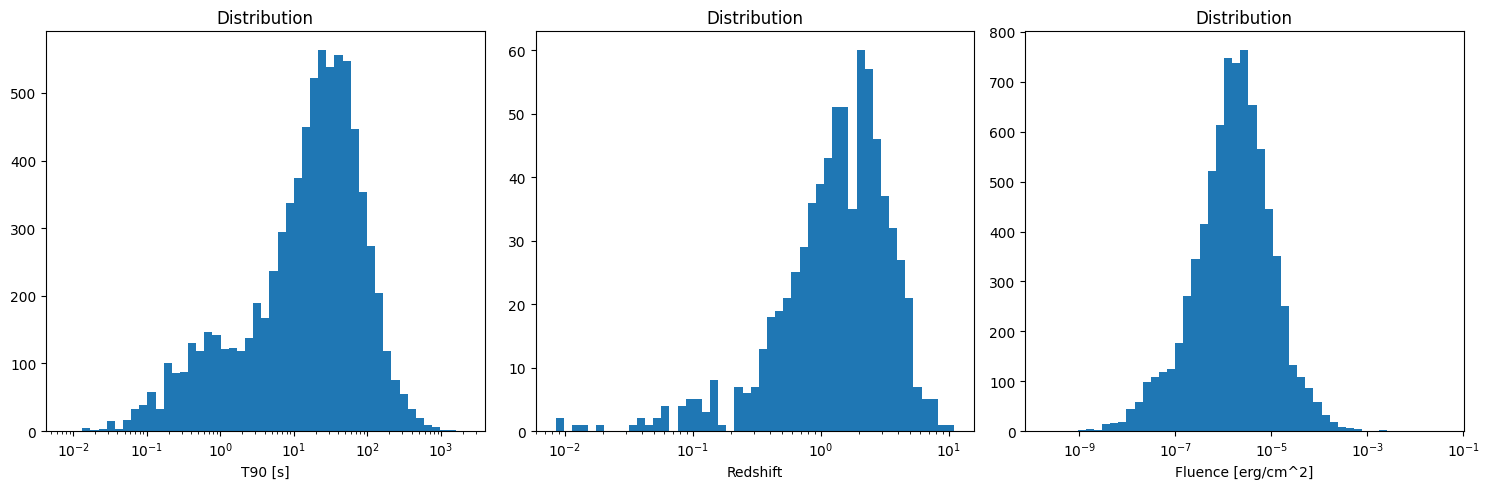

In [45]:
# Plot some distributions of the data. I used log10 space for T90 fluence to better visualize the wide range of values.

min_t90, max_t90 = np.log10(grb['T90'][grb['T90']>0].min()), np.log10(grb['T90'].max()) 
bins_T90 = np.logspace(min_t90, max_t90, 50) # 50 bins evenly spaced in log-scale
min_fluence, max_fluence = np.log10(grb['fluence'][grb['fluence']>0].min()), np.log10(grb['fluence'].max())
bins_fluence = np.logspace(min_fluence, max_fluence, 50)
min_redshift, max_redshift = np.log10(grb['redshift'][grb['redshift']>0].min()), np.log10(grb['redshift'].max())
bins_redshift = np.logspace(min_redshift, max_redshift, 50)

plt.figure(figsize=(15, 5))

# Plot T90
plt.subplot(1, 3, 1)
plt.hist(grb['T90'][grb['T90']>0], bins=bins_T90)
plt.xscale("log")
plt.xlabel("T90 [s]")
plt.title('Distribution')

# Plot Redshift
plt.subplot(1, 3, 2)
plt.hist(grb['redshift'][grb['redshift']>0], bins=bins_redshift) 
plt.xscale("log")
plt.xlabel("Redshift")
plt.title('Distribution')

# Plot Fluence
plt.subplot(1, 3, 3)
plt.hist(grb['fluence'][grb['fluence']>0], bins=bins_fluence)
plt.xscale("log")
plt.xlabel("Fluence [erg/cm^2]")
plt.title('Distribution')

plt.tight_layout()
plt.show()

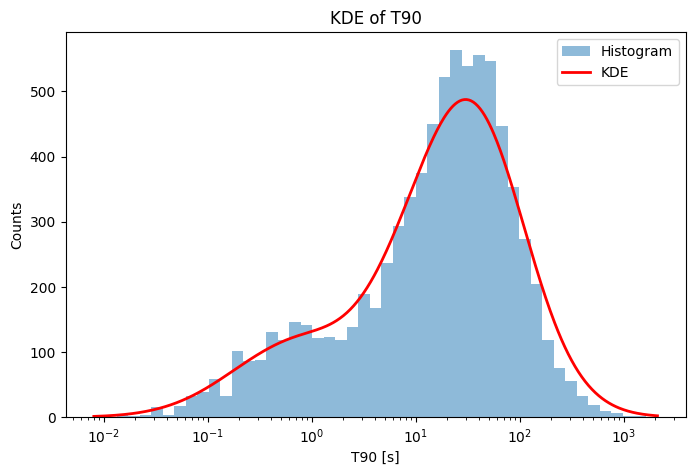

In [46]:
# We can see that T90 shows a bimodal distribution, which is consistent with the known classification of GRBs into short and long categories. 

# KDE to visualize the bimodality of T90
valid_t90 = grb['T90'][grb['T90'] > 0]
valid_fluence = grb['fluence'][grb['fluence'] > 0]
N = len(valid_t90)
log_bin_width = np.log10(bins_T90[1]) - np.log10(bins_T90[0]) # Calculate the width of the bins in log space

plt.figure(figsize=(8, 5))
kde = KernelDensity(kernel='gaussian', bandwidth=0.3).fit(np.log10(valid_t90).reshape(-1, 1))

x_d = np.logspace(min_t90, max_t90, 500)
log_dens = kde.score_samples(np.log10(x_d).reshape(-1, 1))

scaled_kde = np.exp(log_dens) * N * log_bin_width # Scale KDE to match histogram counts

plt.hist(grb['T90'], bins=bins_T90, alpha=0.5, label='Histogram')
plt.plot(x_d, scaled_kde, label='KDE', color='red', lw=2)

plt.xscale("log")
plt.xlabel("T90 [s]")
plt.ylabel("Counts")
plt.title('KDE of T90')
plt.legend()
plt.show()

In [47]:
# Now do KDE but with cross validation to check the correct best bandwidht
log_t90 = np.log10(valid_t90)

# Cross validation with K=5
bwrange = np.linspace(0.01, 1.0, 50) 
grid = GridSearchCV(KernelDensity(kernel='gaussian'), {'bandwidth': bwrange}, cv=5)
grid.fit(log_t90[:, np.newaxis])

w_opt = grid.best_params_['bandwidth']
print(f'Optimal bandwidth trovata: {w_opt:.4f}') 


kde_opt = KernelDensity(bandwidth=w_opt, kernel='gaussian').fit(log_t90[:, np.newaxis])




Optimal bandwidth trovata: 0.1110


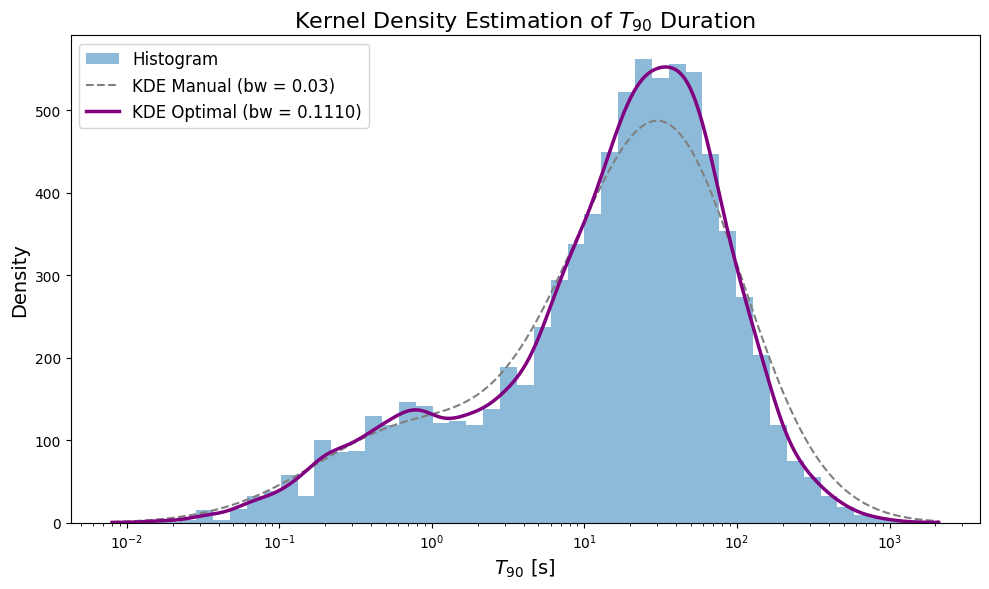

In [58]:
from math import log


log_dens_opt = kde_opt.score_samples(np.log10(x_d).reshape(-1, 1))

scaled_kde_opt = np.exp(log_dens_opt) * N * log_bin_width # Scale KDE to match histogram counts

#Plot of optimal vs previous bandwidht KDE
plt.figure(figsize=(10, 6))

bins_hist = np.logspace(log_t90.min(), log_t90.max(), 50)

plt.hist(grb['T90'], bins=bins_T90, alpha=0.5, label='Histogram')
plt.plot(x_d, scaled_kde, label=f'KDE Manual (bw = {0.03})', color='gray', linestyle='--')
plt.plot(x_d, scaled_kde_opt, label=f'KDE Optimal (bw = {w_opt:.4f})', color='purple', linewidth=2.5)

plt.xlabel(r'$T_{90}$ [s]', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.xscale('log')
plt.title(r'Kernel Density Estimation of $T_{90}$ Duration', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()

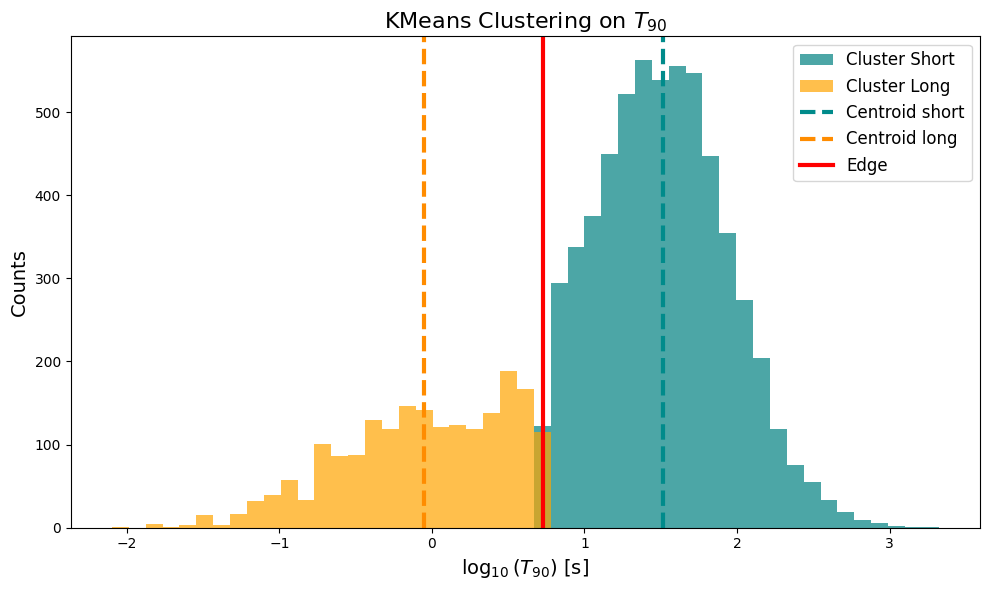

Centroid GBR short: 32.66 s
Centroid GBR long: 0.88 s
treshold : 5.37 s


In [49]:
# Apply K-means to separate GRB-long and GRB-short
kmeans = KMeans(n_clusters=2, n_init='auto')
kmeans.fit(log_t90[:, np.newaxis])
labels = kmeans.labels_
centers = kmeans.cluster_centers_
centers_km = kmeans.cluster_centers_ 
edge_km = np.mean(centers_km)

# Plot
plt.figure(figsize=(10, 6))

cluster_0 = log_t90[labels == 0]
cluster_1 = log_t90[labels == 1]

bins = np.linspace(log_t90.min(), log_t90.max(), 50)

plt.hist(cluster_0, bins=bins, alpha=0.7, color='teal', label='Cluster Short')
plt.hist(cluster_1, bins=bins, alpha=0.7, color='orange', label='Cluster Long')

plt.axvline(centers[0][0], color='darkcyan', linestyle='dashed', linewidth=3, label='Centroid short')
plt.axvline(centers[1][0], color='darkorange', linestyle='dashed', linewidth=3, label='Centroid long')
plt.axvline(edge_km, color='red', linewidth=3, label='Edge')

plt.xlabel(r'$\log_{10}(T_{90})$ [s]', fontsize=14)
plt.ylabel('Counts', fontsize=14)
plt.title(r'KMeans Clustering on $T_{90}$', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()

print(f"Centroid GBR short: {10**centers[0][0]:.2f} s")
print(f"Centroid GBR long: {10**centers[1][0]:.2f} s")
print (f"treshold : {10**edge_km:.2f} s")

Bandwidth estimated: 0.3670
Unique labels: [-1  0  1]
Number of estimated clusters: 2

Cluster 0:
Lower edge: 13.82 s
Center: 31.89 s
Upper edge: 72.99 s

Cluster 1:
Lower edge: 0.45 s
Center: 1.00 s
Upper edge: 2.30 s

Fraction of points assigned to no cluster: 0.4488


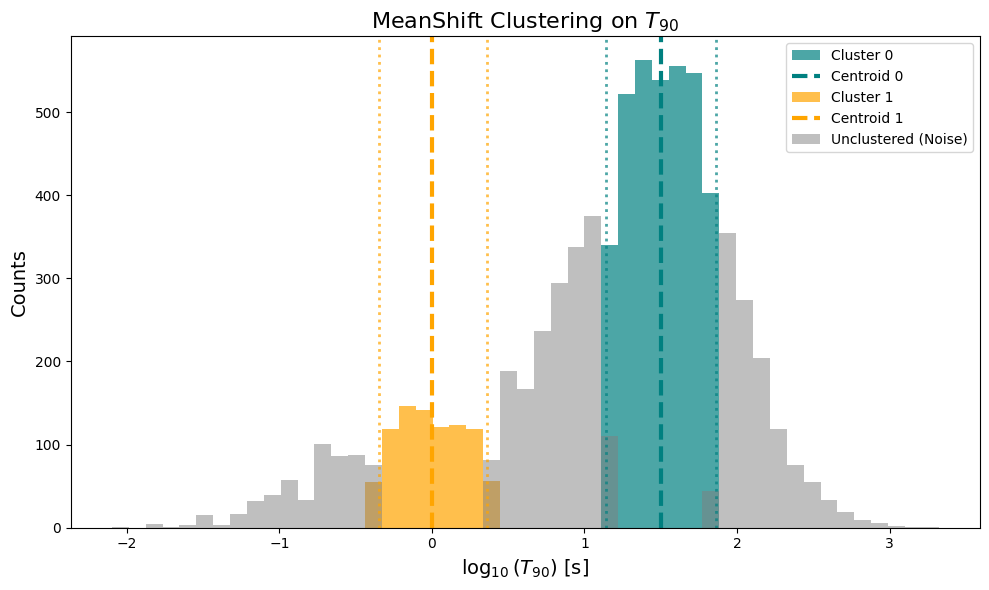

In [55]:
#Now use Meanshift algorithm

b = estimate_bandwidth(log_t90[:, np.newaxis], quantile=0.2) 
print(f'Bandwidth estimated: {b:.4f}')

ms = MeanShift(bandwidth=b, bin_seeding=True, cluster_all=False)
ms.fit(log_t90[:, np.newaxis])

labels_ms = ms.labels_
labels_unique = np.unique(labels_ms)
n_clusters = len(labels_unique[labels_unique >= 0])
centers_ms = ms.cluster_centers_

print("Unique labels:", labels_unique)
print("Number of estimated clusters:", n_clusters)

# Plot
plt.figure(figsize=(10, 6))

bins = np.linspace(log_t90.min(), log_t90.max(), 50)

colors = ['teal', 'orange', 'green', 'purple', 'brown']

# loop over cluster
for i in range(n_clusters):
    cluster_points = log_t90[labels_ms == i]
    center = centers_ms[i][0]
    
    plt.hist(cluster_points, bins=bins, alpha=0.7, color=colors[i % len(colors)], label=f'Cluster {i}')
    
    lower_edge = np.percentile(cluster_points, 0.5)  
    upper_edge = np.percentile(cluster_points, 99.5) 
    
    print(f"\nCluster {i}:")
    print(f"Lower edge: {10**lower_edge:.2f} s")
    print(f"Center: {10**center:.2f} s")
    print(f"Upper edge: {10**upper_edge:.2f} s")
    
    plt.axvline(center, color=colors[i % len(colors)], linestyle='dashed', linewidth=3, label=f'Centroid {i}')
    plt.axvline(lower_edge, color=colors[i % len(colors)], linestyle=':', linewidth=2, alpha=0.7)
    plt.axvline(upper_edge, color=colors[i % len(colors)], linestyle=':', linewidth=2, alpha=0.7)

# unclustered point
unclustered = log_t90[labels_ms == -1]
if len(unclustered) > 0:
    plt.hist(unclustered, bins=bins, alpha=0.5, color='gray', label='Unclustered (Noise)')
    fraction_unclustered = len(unclustered) / len(log_t90)
    print(f'\nFraction of points assigned to no cluster: {fraction_unclustered:.4f}')

# Estetica del grafico (identica a KMeans)
plt.xlabel(r'$\log_{10}(T_{90})$ [s]', fontsize=14)
plt.ylabel('Counts', fontsize=14)
plt.title(r'MeanShift Clustering on $T_{90}$', fontsize=16)

# Spostiamo la legenda leggermente fuori o la compattiamo se ci sono troppe linee
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()

plt.show()

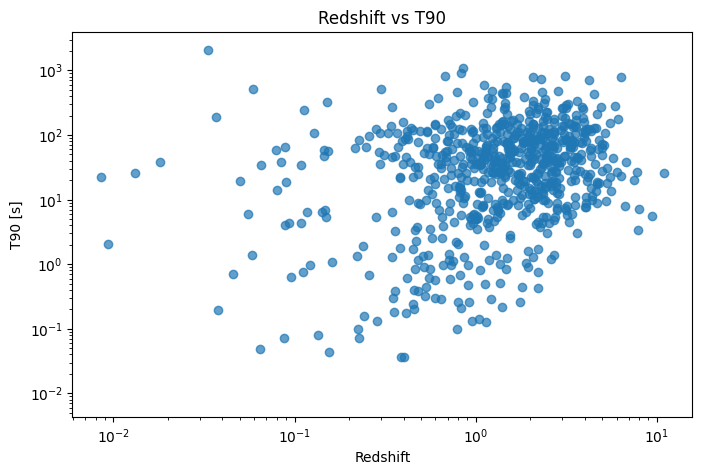

In [ ]:
# We can see some hint of clustering in the T90 vs fluence space, but it's not very clear. 
# Let's try to scatter plot redshift vs T90
plt.figure(figsize=(8, 5))
plt.scatter(grb['redshift'], grb['T90'], alpha=0.7)
plt.xscale("log")
plt.xlabel("Redshift")
plt.ylabel("T90 [s]")
plt.yscale("log")
plt.title('Redshift vs T90')
plt.show()

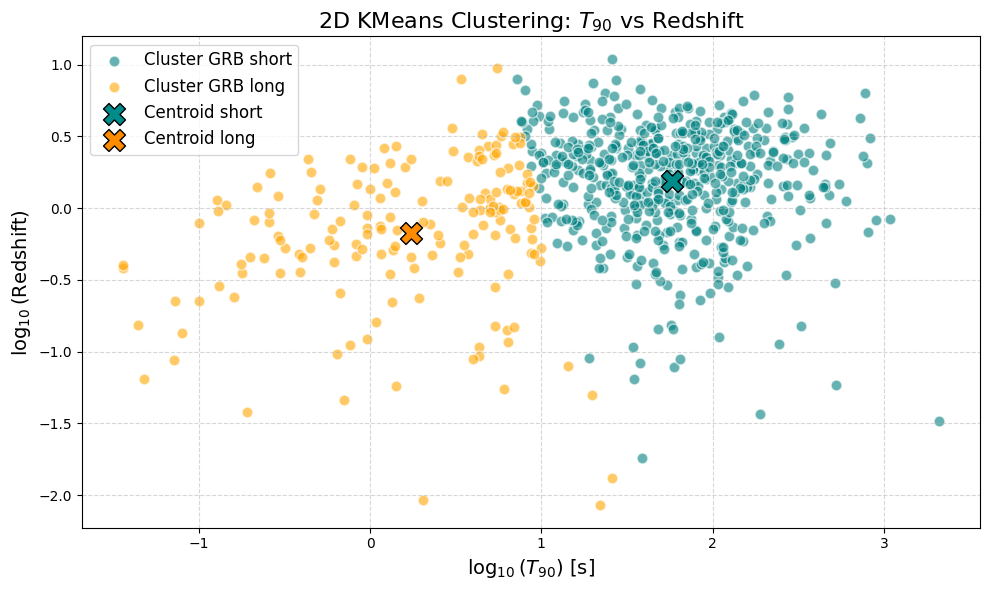

Centroid 0: T90 = 58.26 s, Redshift = 1.5433
Centroid 1: T90 = 1.74 s, Redshift = 0.6691


In [60]:
# T90 vs Redshift clustering with kmeans


# Consider only the point with non null values of both Redshift and t90
valid_value = (grb['T90'] > 0) & (grb['redshift'] > 0)

valid_t90 = grb['T90'][valid_value]
valid_redshift = grb['redshift'][valid_value]

log_t90 = np.log10(valid_t90)
log_redshift = np.log10(valid_redshift)

#create an array with both measuerement
X_2d = np.column_stack((log_t90, log_redshift))

# Kmeans
kmeans_2d = KMeans(n_clusters=2, n_init='auto', random_state=42)
kmeans_2d.fit(X_2d)

labels_2d = kmeans_2d.labels_
centers_2d = kmeans_2d.cluster_centers_

# scatter Plot
plt.figure(figsize=(10, 6))

plt.scatter(X_2d[labels_2d == 0, 0], X_2d[labels_2d == 0, 1], 
            alpha=0.6, c='teal', edgecolors='w', s=60, label='Cluster GRB short')
plt.scatter(X_2d[labels_2d == 1, 0], X_2d[labels_2d == 1, 1], 
            alpha=0.6, c='orange', edgecolors='w', s=60, label='Cluster GRB long')

plt.scatter(centers_2d[0, 0], centers_2d[0, 1], 
            c='darkcyan', marker='X', s=250, edgecolors='black', label='Centroid short')
plt.scatter(centers_2d[1, 0], centers_2d[1, 1], 
            c='darkorange', marker='X', s=250, edgecolors='black', label='Centroid long')

plt.xlabel(r'$\log_{10}(T_{90})$ [s]', fontsize=14)
plt.ylabel(r'$\log_{10}(\text{Redshift})$', fontsize=14)
plt.title(r'2D KMeans Clustering: $T_{90}$ vs Redshift', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()

print(f"Centroid 0: T90 = {10**centers_2d[0, 0]:.2f} s, Redshift = {10**centers_2d[0, 1]:.4f}")
print(f"Centroid 1: T90 = {10**centers_2d[1, 0]:.2f} s, Redshift = {10**centers_2d[1, 1]:.4f}")
